In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

In [ ]:
animal = 

In [11]:
conn = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_50/{animal}.npy")

In [12]:
coord = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/coords/{animal}.npy")

In [34]:
coord.shape

(200, 3)

In [ ]:
np.min(coord[:,0]), np.min(coord[:,1]), np.min(coord[:,2])

# OTTER
# (np.float64(20.84873949579832),
#  np.float64(26.785714285714285),
#  np.float64(44.82513661202186))

# HORSE
# (np.float64(26.62264150943396),
#  np.float64(10.874074074074073),
#  np.float64(5.069148936170213))

(np.float64(26.62264150943396),
 np.float64(10.874074074074073),
 np.float64(5.069148936170213))

In [ ]:
np.max(coord[:,0]), np.max(coord[:,1]), np.max(coord[:,2]) # 0), np.max(coord,1) # , np.max(coord, 2) 

# OTTER
# (np.float64(108.10924369747899),
#  np.float64(55.32539682539682),
#  np.float64(48.622950819672134))

# HORSE
# (np.float64(123.29787234042553),
#  np.float64(84.78181818181818),
#  np.float64(53.229729729729726))

(np.float64(123.29787234042553),
 np.float64(84.78181818181818),
 np.float64(53.229729729729726))

Horse1 :  Min 5.085784087631862 ,  Max 84.94049106397837
Otter1 :  Min 6.077801974859318 ,  Max 103.11048170703164
Mouse :  Min 3.7379601282168484 ,  Max 81.01068455131129
LemurCatta1 :  Min 4.136703384662144 ,  Max 90.02782509156911


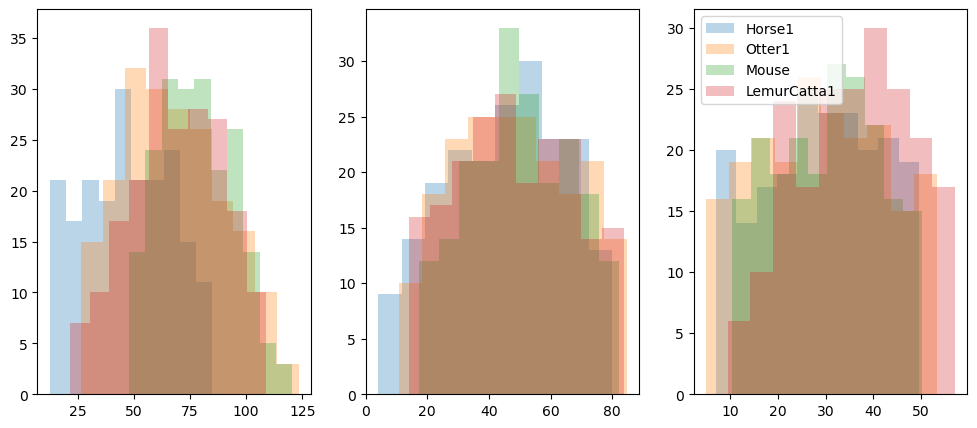

In [42]:
animals = ["Horse1", "Otter1", "Mouse", 
        #    "Tiger",  -> No conn50 available
           "LemurCatta1"]
           

plt.figure(figsize=(12, 5))
for animal in animals: 
    conn = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_50/{animal}.npy")
    coord = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/coords/{animal}.npy")
    
    for i in range(3): 
        plt.subplot(1, 3, i+1)
        plt.hist(coord[:,i], label=animal, alpha=0.3)
        

    # Print the shape and a small sample of the final matrix
    distance_matrix_condensed = pdist(coord)
    print(animal, ":  Min", np.min(distance_matrix_condensed), ",  Max", np.max(distance_matrix_condensed))
        
plt.legend()

In [ ]:
import numpy as np



Shape of the final distance matrix: (200, 200)
Min 4.159586182740769 Max 67.20530425669838


In [ ]:
distance_matrix_condensed.shape

(19900,)

In [45]:
import os
import csv

# --- 1. SET YOUR FOLDER PATHS HERE ---
# Please replace these with the actual paths to your folders.
folder1_path = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/coords'
folder2_path = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_100'
folder3_path = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/connectivity/mami/conn_150'

# Set the name for your output file.
output_csv_path = '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/info/file_availability_report.csv'
# ------------------------------------

def get_base_names_from_folder(folder_path):
    """
    Scans a folder and returns a set of file base names (name without extension).
    Returns an empty set if the folder doesn't exist.
    """
    if not os.path.isdir(folder_path):
        print(f"⚠️ Warning: Directory not found: {folder_path}")
        return set()
    
    # os.path.splitext('file.ext') returns ('file', '.ext')
    # We take the first part [0] which is the base name.
    return {os.path.splitext(f)[0] for f in os.listdir(folder_path)}

# Get the unique base names from each directory
base_names1 = get_base_names_from_folder(folder1_path)
base_names2 = get_base_names_from_folder(folder2_path)
base_names3 = get_base_names_from_folder(folder3_path)

# Combine all unique base names from all folders into one sorted list
all_unique_names = sorted(list(base_names1.union(base_names2, base_names3)))

# Prepare the data for the CSV file
csv_rows = [['animal', 'in_coords', 'in_conn_100', 'nix']] # in_preprocessed_data']]

for name in all_unique_names:
    row = [
        name,
        '1' if name in base_names1 else '0', # 1: yes, 0: no
        '1' if name in base_names2 else '0',
        '1' if name in base_names3 else '0'
    ]
    csv_rows.append(row)

# Write the data to the CSV file
try:
    with open(output_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(csv_rows)
    print(f"✅ Success! Report saved to: {output_csv_path}")
except IOError as e:
    print(f"❌ Error: Could not write to file {output_csv_path}. Reason: {e}")

✅ Success! Report saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/suarez_MaMI_dataset/info/file_availability_report.csv
